Name: Syed Saud Ali    
Title: Analysis on HDB and housing in Singapore   

URL List:                
       
1.This dataset finds out the demand of rental flat and flat sold demand:   
https://beta.data.gov.sg/datasets?query=HDB&formats=CSV&resultId=d_4b4ee36346b27fe35c529588900340b2     
2.This dataset finds out the HDB household by flat type:   
https://beta.data.gov.sg/datasets?formats=CSV&query=flat+type&resultId=d_db69c88a1ff684356b8b38dc0e9b432c   
3.This dataset finds out the resident population by geogrpahic distribution:   
https://beta.data.gov.sg/datasets?formats=CSV&query=HDB+geograpical&resultId=d_0a6c6d71f6fa14e2d27e406f1d018439   
4.This dataset finds the resale price based on registration date from the start of 2017 onwards:   
https://beta.data.gov.sg/datasets?formats=CSV&query=hdb+price&resultId=d_8b84c4ee58e3cfc0ece0d773c8ca6abc   

Questions:       
1.Which town has the highest number of residents for 2 different years?(Bar Chart)   
2.How many flats were rented and sold every few years?(Line Chart)   
3.What is the distribution of the HDB household by flat type?(Pie Chart)   
4.Is there any correlation between the floor area and the resale price of the flat?(Scatter Plot)   
5.What is the distribution of resale price of flat by flat model?(Box Plot)   

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Set display format for float to avoid scientific notation
pd.options.display.float_format = '{:,.2f}'.format
import matplotlib.ticker as ticker
import seaborn as sns
### Save file into a variable
FlatDemandFile='DemandforRentalandSoldFlats.csv';
FlatTypeFile='HDBHouseholdsbyFlatType.csv';
ResidentPopulationFile='HDBResidentPopulationbyGeographicalDistribution.csv';
ResaleFlatFile='ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv';
### Read csv file contents
FlatDemandData=pd.read_csv(FlatDemandFile);
FlatTypeData=pd.read_csv(FlatTypeFile);
ResidentPopulationData=pd.read_csv(ResidentPopulationFile);
ResaleFlatData=pd.read_csv(ResaleFlatFile);

The dataset below shows the population of residents by geograhpical location.

In [22]:
print(f'Statistical Summary for {ResidentPopulationFile}');
### Find the number of rows and columns in the dataset
print(f"This dataset has {ResidentPopulationData.shape[0]} rows of data and {ResidentPopulationData.shape[1]} columns of data");
### Find the name of all the columns in the dataset
print(f"The columns in the dataset are {list(ResidentPopulationData.columns)}");
### Find the datatypes for each column in the dataset
print(f"The datatype for each column in the dataset is {list(ResidentPopulationData.dtypes)} based on the column names above");
### Find information about the dataset
print(f"Below is the information relating to the dataset");
print(ResidentPopulationData.info);
### Find a more descriptive statistical summary for one of the columns in the dataset
print("A decriptive statistical summary for resident population in the dataset");
print(ResidentPopulationData['number'].describe());

Statistical Summary for HDBResidentPopulationbyGeographicalDistribution.csv
This dataset has 104 rows of data and 3 columns of data
The columns in the dataset are ['shs_year', 'town_estate', 'number']
The datatype for each column in the dataset is [dtype('int64'), dtype('O'), dtype('int64')] based on the column names above
Below is the information relating to the dataset
<bound method DataFrame.info of      shs_year    town_estate  number
0        2003       Sengkang  123726
1        2003        Punggol   38290
2        2003      Sembawang   57033
3        2003      Woodlands  210723
4        2003    Jurong_west  216722
..        ...            ...     ...
99       2018     Queenstown   76000
100      2018        Geylang   75400
101      2018       Clementi   70200
102      2018   Central Area   30300
103      2018  Marine Parade   18700

[104 rows x 3 columns]>
A decriptive statistical summary for resident population in the dataset
count       104.00
mean    114,086.29
std      61,946

Based on the data above, we can see that the average overall resident population in the dataset is around 114000 people, with the spread of data in relation to the mean being almost 62000 people.

Now to answer the question:Which town has the highest number of residents for 2 different years? Let us answer it by using a Bar Graph.For this question, we are going to use the 2 most recent year given to gather the most recent insights from the dataset, being 2018 and 2013 respectively.

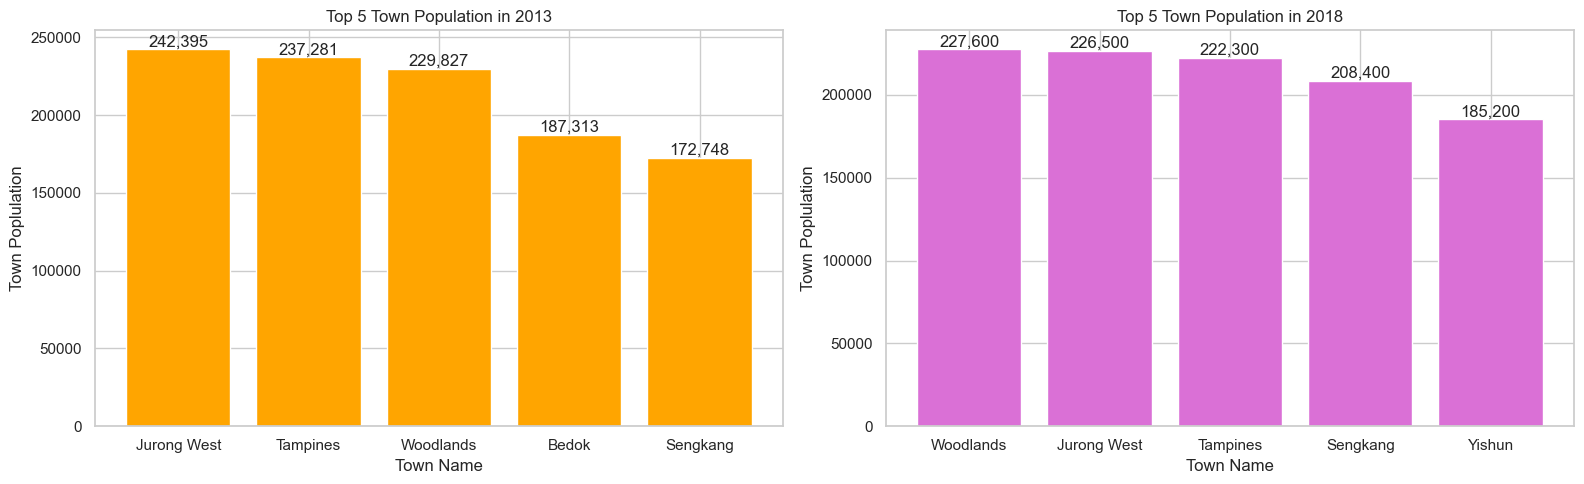

In [23]:
### function for camel casing
def CamelCaseWithProperSpacing(txt):
    if "_" in txt:
        txt=txt.replace("_"," ");
    return txt.title();
### Apply casing to Population dataset
ResidentPopulationData['town_estate']=ResidentPopulationData['town_estate'].apply(CamelCaseWithProperSpacing);
### Filter data by 2018 and 2013
ResidentPopulationData2018=ResidentPopulationData[ResidentPopulationData['shs_year']==2018];
ResidentPopulationData2013=ResidentPopulationData[ResidentPopulationData['shs_year']==2013];
### Sort the data by population in descending order
SortTownPopulation2018=ResidentPopulationData2018.sort_values(by='number',ascending=False);
SortTownPopulation2013=ResidentPopulationData2013.sort_values(by='number',ascending=False);
### Get Top 5 tows with highest population
Top5TownPopulation2018=SortTownPopulation2018[:5];
Top5TownPopulation2013=SortTownPopulation2013[:5];
### Create subplots
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(16,5));
### Create a container to be used for data labels in the output
container2013 = ax[0].bar(Top5TownPopulation2013['town_estate'],Top5TownPopulation2013['number'],color='orange');
### Create the rest of the bar chart 
ax[0].set(title='Top 5 Town Population in 2013',ylabel='Town Poplulation',xlabel='Town Name');
ax[0].bar_label(container2013,label_type='edge',fmt='{:,.0f}');
ax[0].grid(True);
### Create a container to be used for data labels in the output
container2018 = ax[1].bar(Top5TownPopulation2018['town_estate'],Top5TownPopulation2018['number'],color='orchid');
### Create the rest of the bar chart 
ax[1].set(title='Top 5 Town Population in 2018',ylabel='Town Poplulation',xlabel='Town Name');
ax[1].bar_label(container2018,label_type='edge',fmt='{:,.0f}');
ax[1].grid(True);
plt.tight_layout();
plt.show();

The town with the highest population in 2013 is Jurong West with almost 242 and a half thousand people living inside it.In 2018, it has has been reduced to the number 2 spot in 2018, with its population also dropping to 226 thousand individuals.Instead, the town with the highest population in 2018 is now Wodlands, which has improved its spot compared to 2013 where it was the third most populous town despite a slightly reduced population size of almost 230 thousand in 2013 to around 227 and a half thousand in 2018.Finally,the town of Bedok used to be inside the top 5 most populous town recorded in 2013 but is no longer inside the top 5 most populous towns in 2018, where its spot is instead taken by Yishun.

The dataset below shows the number of rented and sold flats each year.

In [24]:
print(f"Statistical summary for {FlatDemandFile}");
### Find the number of rows and columns in the dataset
print(f"This dataset has {FlatDemandData.shape[0]} rows of data and {FlatDemandData.shape[1]} columns of data");
### Find the name of all the columns in the dataset
print(f"The columns in the dataset are {list(FlatDemandData.columns)}");
### Find the datatypes for each column in the dataset
print(f"The datatype for each column in the dataset is {list(FlatDemandData.dtypes)} based on the column names above");
### Find information about the dataset
print(f"Below is the information relating to the dataset");
print(FlatDemandData.info);
### Find a more descriptive statistical summary for one of the columns in the dataset
print("A decriptive statistical summary for flat demand in the dataset");
print(FlatDemandData['demand_for_flats'].describe());

Statistical summary for DemandforRentalandSoldFlats.csv
This dataset has 26 rows of data and 4 columns of data
The columns in the dataset are ['start_year', 'end_year', 'flat_type', 'demand_for_flats']
The datatype for each column in the dataset is [dtype('int64'), dtype('int64'), dtype('O'), dtype('int64')] based on the column names above
Below is the information relating to the dataset
<bound method DataFrame.info of     start_year  end_year             flat_type  demand_for_flats
0         1960      1965          rental_flats             52408
1         1960      1965  home_ownership_flats              2967
2         1966      1970          rental_flats             66005
3         1966      1970  home_ownership_flats             40013
4         1971      1975          rental_flats             57034
5         1971      1975  home_ownership_flats            123213
6         1976      1980          rental_flats             47958
7         1976      1980  home_ownership_flats           

Based on the data above, we can find the average flat demand in the dataset is almost 77 and a half thousand flats, with the spread of the demand in relation to the mean being around 72 thousand flats.

Now to answer the question: How many flats were rented and sold every few years? We are going to use a line chart to find the combined demand of rented flat and sold flats.In order to be more accurate in the findings, we are going to filter the dataset to only show the demand from 1986 to 2020 in order to have more recent data for our analysis and records data every 4 years only.

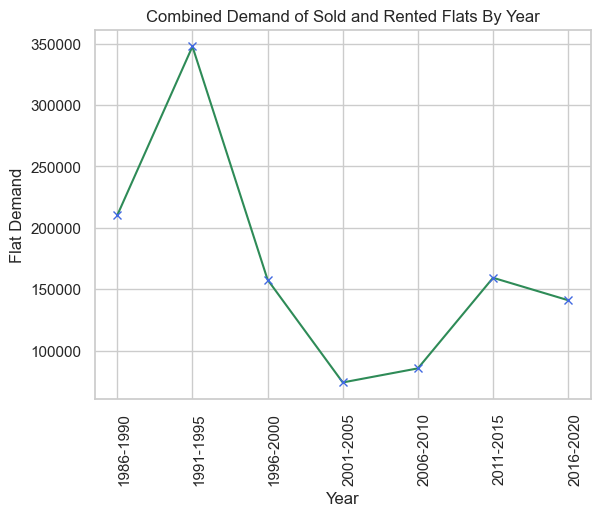

In [25]:
### Filter data from 1986 to 2020
FlatDemand8620=FlatDemandData[(FlatDemandData['start_year']>=1986) & (FlatDemandData['end_year']<=2020)];
### Find the total flat demand by adding up the rented and sold flats together
OverallFlatDemand=FlatDemand8620.groupby(['start_year','end_year']).sum(numeric_only=True);
### Resetting the index to make the start and end year accessible
OverallFlatDemand.reset_index(inplace=True);
### Create a new list for x-labels
XLabelList=[];
for index,row in OverallFlatDemand.iterrows():
    XLabelList.append(str(row['start_year'])+"-"+str(row['end_year']));
### Create a Line Graph
plt.title('Combined Demand of Sold and Rented Flats By Year');
plt.xlabel('Year');
plt.ylabel('Flat Demand');
plt.xticks(np.arange(len(XLabelList)),XLabelList,rotation=90,ha='left');
plt.plot(XLabelList,OverallFlatDemand['demand_for_flats'].tolist(),color='seagreen',marker='x',markeredgecolor='royalblue');
plt.grid(True);
plt.show();

We can see from the graph that the demand for flats has decreased overall from slightly more than 200 thousand in 1986 to 1990 to almost 150 thousand in 2016 to 2020.The decline can be majorily attributed from 1995 to 2005, where the demand has reduced significantly from almost 350 thousand flats at the end of 1995 to less than 100 thousand at the end of 2005, which is a nearly a whopping 80% decrease in flat demand.After that, it has seen a gradual increase in the flat demand peaking at 2011 to 2015 of above 150 thousand flats before decreasing slightly to less than 150 thousand from 2016 to 2020.Finally, there has also been an increase in demand for flats from 1986 to 1995 from more than 200 thousand flats to around 350 thousand flats, which accounts for around 65% increase in demand during that time period.

The dataset below shows the number of households with their respective flat types.

In [26]:
print(f"Statistical summary for {FlatTypeFile}");
### Find the number of rows and columns in the dataset
print(f"This dataset has {FlatTypeData.shape[0]} rows of data and {FlatTypeData.shape[1]} columns of data");
### Find the name of all the columns in the dataset
print(f"The columns in the dataset are {list(FlatTypeData.columns)}");
### Find the datatypes for each column in the dataset
print(f"The datatype for each column in the dataset is {list(FlatTypeData.dtypes)} based on the column names above");
### Find information about the dataset
print(f"Below is the information relating to the dataset");
print(FlatTypeData.info);
### Find a more descriptive statistical summary for one of the columns in the dataset
print("A decriptive statistical summary for the number of households in the dataset");
print(FlatTypeData['no_of_households'].describe());

Statistical summary for HDBHouseholdsbyFlatType.csv
This dataset has 18 rows of data and 3 columns of data
The columns in the dataset are ['shs_year', 'flat_type', 'no_of_households']
The datatype for each column in the dataset is [dtype('int64'), dtype('O'), dtype('int64')] based on the column names above
Below is the information relating to the dataset
<bound method DataFrame.info of     shs_year  flat_type  no_of_households
0       2008     1-room             18562
1       2008     2-room             28614
2       2008     3-room            213857
3       2008     4-room            331739
4       2008     5-room            206799
5       2008  Executive             66455
6       2013     1-room             24573
7       2013     2-room             34204
8       2013     3-room            216163
9       2013     4-room            354526
10      2013     5-room            214074
11      2013  Executive             64959
12      2018     1-room             30369
13      2018     2-room

Based on the data above, we can find the average number of households in the dataset is almost 155 thousand, with the spread of households in relation to the mean being around 127 thousand.

Now to answer the question: What is the distribution of the HDB household by flat type? to find out, we are going to use a pie chart.In order to present most recent findings we are only going to use the data collected in 2018 for more accurate findings.

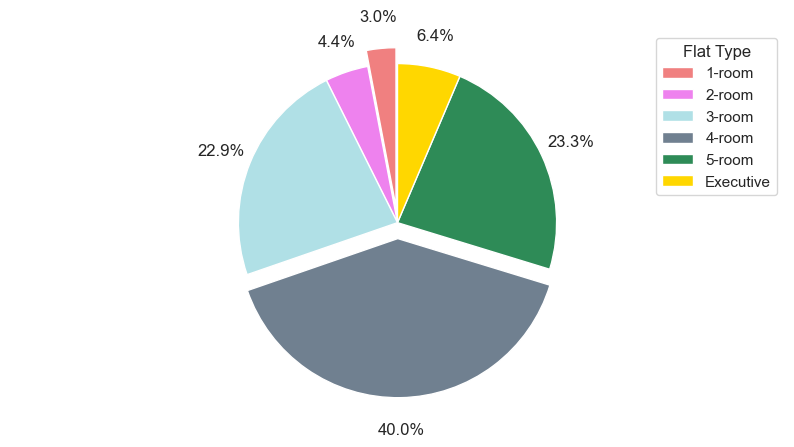

In [27]:
FlatTypeData2018=FlatTypeData[FlatTypeData['shs_year']==2018];
### Create labels for the pie chart
label_text=['1-room','2-room','3-room','4-room','5-room','Executive'];
exp=(0.1,0,0,0.1,0,0);
colors=['lightcoral','violet','powderblue','slategrey','seagreen','gold'];
### Create pie chart
fig, ax = plt.subplots(figsize=(10,5));
ax.pie(FlatTypeData2018['no_of_households'].tolist(), explode=exp, autopct='%1.1f%%', startangle=90, pctdistance=1.2, colors=colors);
ax.axis('equal');
plt.legend(title='Flat Type', labels=label_text);
plt.show();

We can see that the flat type with the most number of households is 4 rooms where it represents 40% of the whole filtered dataset. The 3 room and 5 room flat types are similary distributed with them being 22.9% and 23.3% respecively.Finally, the least popular flat type is 1 room where it accounts for less than 5% of the whole pie chart, which accounts to less than 1/8 of the most popular flat type of 4 room.

The dataset below shows the price of the flat based on the registration date from 2017 onwards.

In [28]:
print(f'Statistical Summary for {ResaleFlatFile}');
### Find the number of rows and columns in the dataset
print(f"This dataset has {ResaleFlatData.shape[0]} rows of data and {ResaleFlatData.shape[1]} columns of data");
### Find the name of all the columns in the dataset
print(f"The columns in the dataset are {list(ResaleFlatData.columns)}");
### Find the datatypes for each column in the dataset
print(f"The datatype for each column in the dataset is {list(ResaleFlatData.dtypes)} based on the column names above");
### Find information about the dataset
print(f"Below is the information relating to the dataset");
print(ResaleFlatData.info);
### Find a more descriptive statistical summary for one of the columns in the dataset
print("A decriptive statistical summary for resale price in the dataset");
print(ResaleFlatData['resale_price'].describe());

Statistical Summary for ResaleflatpricesbasedonregistrationdatefromJan2017onwards.csv
This dataset has 184600 rows of data and 11 columns of data
The columns in the dataset are ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'floor_area_sqm', 'flat_model', 'lease_commence_date', 'remaining_lease', 'resale_price']
The datatype for each column in the dataset is [dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('O'), dtype('float64'), dtype('O'), dtype('int64'), dtype('O'), dtype('float64')] based on the column names above
Below is the information relating to the dataset
<bound method DataFrame.info of           month        town  flat_type block        street_name storey_range  \
0       2017-01  ANG MO KIO     2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1       2017-01  ANG MO KIO     3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2       2017-01  ANG MO KIO     3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3       2017-01  ANG MO KIO     3

From the data above, the average retail price of the flats registered after the start of 2017 is around half a million, with the spread of data in relation to the mean being around 175 thousand.

Now to answer the question: Is there any correlation between the floor area and the resale price of the flat? to find out we are going to use a scatter plot to find out.Due to the sheer size of the dataset and to only analyze the most current data, I have decided to only filter it from 2015 onwards in terms of lease commence date.

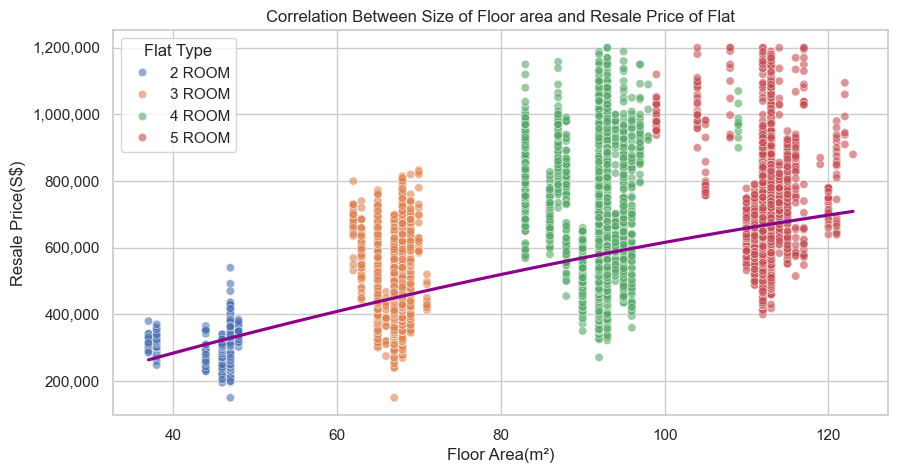

In [29]:
ResaleFlatData2015=ResaleFlatData[(ResaleFlatData['lease_commence_date']>=2015) & (ResaleFlatData['resale_price']<=1200000)];
sns.set_theme(style='whitegrid');
### Change Figure Size
plt.figure(figsize=(10,5));
### Set the formatter for the y-axis to disable scientific notation
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'));
### Generate a scatter plot
sns.scatterplot(x='floor_area_sqm',y='resale_price',hue='flat_type', hue_order=['2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM'], data=ResaleFlatData2015, alpha=0.6, palette='deep');
### Generate a trend line
sns.regplot(data=ResaleFlatData2015, x='floor_area_sqm',y='resale_price', order=2, scatter=False, color='darkmagenta');
### Label the graph
plt.title("Correlation Between Size of Floor area and Resale Price of Flat");
plt.xlabel('Floor Area(m²)');
plt.ylabel('Resale Price(S$)');
plt.legend(title='Flat Type');

We can see that the overall, there is a positive correlation, as the floor area of the flat increases, the resale price of the flat also increases.The trendline shows very little curve, which shows that there is little to no difference in the rate of increase from the beginning of the graph to the end of the graph.There are some outliers despite some flats having more that 60 square metres of floor area, the resale price of the same flat is below 200 thousand dollars, which makes it comparable to other flats with a smaller floor area, showing that there are other factors that can have an impact on the resale price.

While still using the same dataset as the one for the scatter plot, we are now going to answer this question: What is the distribution of resale price of flat by flat model? where we are going to use a boxplot to find out.

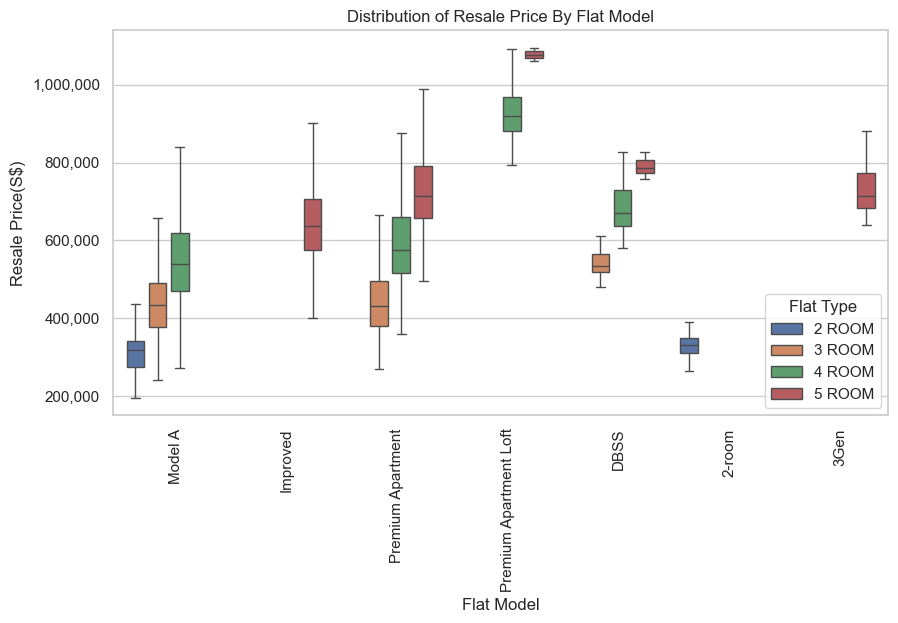

In [30]:
sns.set_theme(style='whitegrid');
### Change Figure Size
plt.figure(figsize=(10,5));
### Set the formatter for the y-axis to disable scientific notation
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')); 
### Plot the boxplot
sns.boxplot(data=ResaleFlatData2015,x='flat_model',y='resale_price',hue='flat_type',hue_order=['2 ROOM','3 ROOM','4 ROOM','5 ROOM'],dodge=True, gap=0.2, showfliers=False);
### Label the graph
plt.title("Distribution of Resale Price By Flat Model");
plt.xlabel("Flat Model");
plt.xticks(rotation=90, ha='left');
plt.ylabel("Resale Price(S$)");
plt.legend(title='Flat Type');

We can see that flat model called 'DBSS' has the smallest interquartile range, particularly the in the 5 room configuration, showing that the resale price are the most consistent compared to other flat types and their respective flat models.The flat models with the highest variation in terms of resale price is Premium Apartment and Model A, where they show similar interquartile ranges overall, with the only difference being that Model A's median price is lower than Premium Apartment's median price, indicating that Model A is the more affordable flat model compared to Premium Apartment.

We have therefore concluded all the questions answered about HDB and housing where we plot graphs using seaborn and matplotlib.plplot and pandas for data summary.